# Análise Econométrica do IBOVESPA e Testes de Significância das Estratégias
## Versão 2 — com taxa livre de risco variável (CDI diário real)

**TCC — Pedro Augusto Pinheiro Reis · Ciências Contábeis · UFG**

Esta é uma versão atualizada do notebook econométrico anterior, com **uma mudança metodológica
relevante**: a taxa livre de risco passa de uma constante (0,0369% a.d., média histórica) para a
**série diária real do CDI** obtida via API do Banco Central. A mudança é importante porque o CDI
diário variou entre ~0,007% a.d. (mínimo histórico em ago/2020–mar/2021) e ~0,052% a.d. (pico de
SELIC a 13,75% em 2022–2023). Usar a média de 0,037% subestima brutalmente o $r_f$ em períodos de
aperto monetário e superestima em períodos de afrouxamento, distorcendo Sharpe, Sortino e o
intercepto da regressão CAPM.

## Estrutura
- **Bloco 1 — Caracterização do *benchmark*** (sem dependência de $r_f$): ADF, KPSS, Ljung-Box,
  ARCH-LM, Jarque-Bera, Variance Ratio.
- **Bloco 2 — Modelagem dinâmica de volatilidade**: GARCH(1,1), GJR-GARCH e EGARCH, com cálculo
  do δ condicional do CAPM reverso usando **CDI variável**.
- **Bloco 3 — Inferência sobre as estratégias** (depende de $r_f$): Jobson-Korkie/Memmel, CAPM
  com Newey-West, *stationary bootstrap*, *spanning test* — todos com $r_f$ variável.
- **Apêndice K e L** para o TCC, formatados em ABNT.

## Status dos insumos
- ✓ **IBOVESPA**: `ibov_diario_2010_2026.csv` (gerado em notebook anterior)
- ✓ **CDI diário real**: `cdi_diario_bcb_2010_atual.csv` (gerado em notebook anterior)
- ☐ **Retornos da estratégia** (`strategy_returns.csv`): aguardando os notebooks 7-10 do pipeline
  rodarem os otimizadores. O Bloco 3 segue usando estratégia sintética **claramente rotulada**
  como *placeholder*, apenas para validar a infraestrutura. Quando os retornos reais existirem,
  basta colocar o CSV no diretório de inputs e re-executar.

## 1. Configuração e funções auxiliares

In [ ]:
import warnings, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

from arch import arch_model
from arch.unitroot import VarianceRatio

warnings.filterwarnings("ignore")
np.random.seed(42)

# Caminhos relativos à raiz do projeto (usando pathlib puramente)
parent_path = Path.cwd().parent.parent

INPUT_DIR_IBOV  = parent_path / "data" / "Ibov"/ "Ibov_Diario"
INPUT_DIR_CDI = parent_path / "data" / "CDI"
INPUT_DIR_STRATEGY = parent_path / "data" / "Strategy"

OUTPUT_DIR =  parent_path / "data" / "Estrategia"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRADING_DAYS = 252
CDI_CONSTANTE_FALLBACK = 0.000369  # 0,0369% a.d. — média histórica (Seção 3.4.1 do TCC original)
                                    # Usado APENAS se a série diária do CDI não estiver disponível.

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (11, 4), "axes.grid": True})


In [3]:
# ---------- Funções utilitárias ----------

def _alinhar_rf(rf, retornos):
    "Alinha rf à série de retornos. rf pode ser float ou Series indexada por data."
    if isinstance(rf, pd.Series):
        if isinstance(retornos.index, pd.DatetimeIndex):
            return rf.reindex(retornos.index).ffill().bfill()
        # retornos sem DatetimeIndex: pega os N últimos valores de rf
        return pd.Series(rf.values[-len(retornos):], index=retornos.index)
    return pd.Series(float(rf), index=retornos.index)

def sharpe(retornos, rf=None):
    if rf is None: rf = CDI_CONSTANTE_FALLBACK
    rf_a = _alinhar_rf(rf, retornos)
    excesso = retornos - rf_a
    return excesso.mean() / excesso.std() * np.sqrt(TRADING_DAYS)

def sortino(retornos, rf=None):
    if rf is None: rf = CDI_CONSTANTE_FALLBACK
    rf_a = _alinhar_rf(rf, retornos)
    excesso = retornos - rf_a
    downside = excesso[excesso < 0]
    if len(downside) == 0: return np.inf
    dd = np.sqrt((downside ** 2).mean())
    return excesso.mean() / dd * np.sqrt(TRADING_DAYS)

def sharpe_de_excesso(excesso):
    return excesso.mean() / excesso.std() * np.sqrt(TRADING_DAYS)

def sortino_de_excesso(excesso):
    downside = excesso[excesso < 0]
    if len(downside) == 0: return np.inf
    dd = np.sqrt((downside ** 2).mean())
    return excesso.mean() / dd * np.sqrt(TRADING_DAYS)

def cagr(retornos):
    n = len(retornos)
    return (1 + retornos).prod() ** (TRADING_DAYS/n) - 1

def max_drawdown(retornos):
    eq = (1 + retornos).cumprod()
    return ((eq - eq.cummax()) / eq.cummax()).min()

def fmt_pvalor(p):
    if p < 0.001: return "< 0,001 ***"
    if p < 0.01:  return f"{p:.4f} ***"
    if p < 0.05:  return f"{p:.4f} **"
    if p < 0.10:  return f"{p:.4f} *"
    return f"{p:.4f}"


### 1.1 Carregamento dos insumos (IBOV e CDI)

In [4]:
# ----- IBOV -----
_ibov_candidatos = [INPUT_DIR_IBOV / "ibov_diario_2010_2026.csv"]
ibov_path = next((p for p in _ibov_candidatos if p.exists()), None)
if ibov_path is None:
    raise FileNotFoundError("ibov_diario_2010_2026.csv não encontrado.")
ibov = pd.read_csv(ibov_path, parse_dates=["data"])
ibov = ibov.dropna(subset=["ibov_ret_simples"]).reset_index(drop=True)

# ----- CDI -----
_cdi_candidatos = [INPUT_DIR_CDI / "cdi_diario_bcb_2010_atual.csv"]
cdi_path = next((p for p in _cdi_candidatos if p.exists()), None)
if cdi_path is None:
    print("[AVISO] CSV do CDI não encontrado. Usando constante de fallback "
          f"({CDI_CONSTANTE_FALLBACK*100:.4f}% a.d.). Métricas dependentes de rf perdem "
          "qualidade. Rode antes o notebook Download_Analise_CDI_SELIC.")
    RF = CDI_CONSTANTE_FALLBACK
    USAR_CDI_SERIE = False
else:
    cdi_df = pd.read_csv(cdi_path, parse_dates=["data"])
    RF = cdi_df.set_index("data")["cdi_diario"]  # série em fração diária
    USAR_CDI_SERIE = True
    print(f"IBOV:  {ibov_path.name}  -  {len(ibov):,} pregões "
          f"({ibov['data'].min().date()} → {ibov['data'].max().date()})")
    print(f"CDI:   {cdi_path.name}  -  {len(RF):,} observações "
          f"({RF.index.min().date()} → {RF.index.max().date()})")
    print(f"\nCDI — estatísticas históricas:")
    print(f"  Média:    {RF.mean()*100:.5f}% a.d.  ({((1+RF.mean())**TRADING_DAYS-1)*100:.2f}% a.a.)")
    print(f"  Mediana:  {RF.median()*100:.5f}% a.d.")
    print(f"  Mínima:   {RF.min()*100:.5f}% a.d.  ({((1+RF.min())**TRADING_DAYS-1)*100:.2f}% a.a.)  em {RF.idxmin().date()}")
    print(f"  Máxima:   {RF.max()*100:.5f}% a.d.  ({((1+RF.max())**TRADING_DAYS-1)*100:.2f}% a.a.)  em {RF.idxmax().date()}")


IBOV:  ibov_diario_2010_2026.csv  -  3,966 pregões (2010-01-05 → 2025-12-30)
CDI:   cdi_diario_bcb_2010_atual.csv  -  4,019 observações (2010-01-04 → 2025-12-31)

CDI — estatísticas históricas:
  Média:    0.03685% a.d.  (9.73% a.a.)
  Mediana:  0.04013% a.d.
  Mínima:   0.00747% a.d.  (1.90% a.a.)  em 2020-08-06
  Máxima:   0.05513% a.d.  (14.90% a.a.)  em 2025-06-20


### 1.2 Visualização do CDI ao longo do período

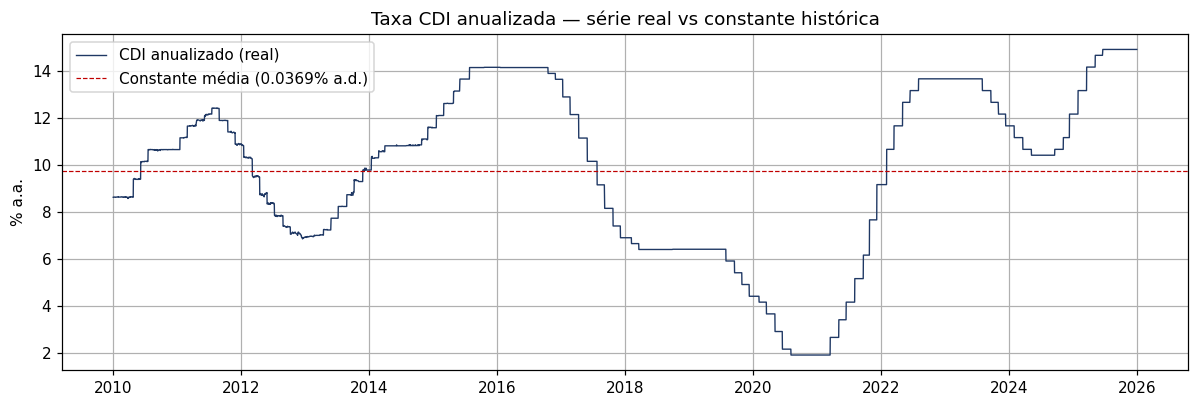

In [5]:
if USAR_CDI_SERIE:
    fig, ax = plt.subplots(figsize=(11, 3.8))
    cdi_anual = ((1 + RF)**TRADING_DAYS - 1) * 100
    ax.plot(RF.index, cdi_anual, lw=0.9, color="#1F3864", label="CDI anualizado (real)")
    ax.axhline(((1+CDI_CONSTANTE_FALLBACK)**TRADING_DAYS-1)*100, color="#C00000", ls="--",
               lw=0.8, label=f"Constante média ({CDI_CONSTANTE_FALLBACK*100:.4f}% a.d.)")
    ax.set_title("Taxa CDI anualizada — série real vs constante histórica")
    ax.set_ylabel("% a.a."); ax.legend()
    plt.tight_layout(); plt.show()


## 2. Bloco 1 — Caracterização econométrica do *benchmark*

Os testes desta seção independem de $r_f$ e replicam, para o IBOVESPA, o diagnóstico apresentado
na Tabela 7 do TCC para os 130 ativos. A simetria metodológica reforça que o *benchmark* exibe as
mesmas patologias estatísticas dos ativos individuais (não-normalidade, ARCH, não-estacionariedade
do nível).

### 2.1 Estacionariedade — ADF e KPSS

In [6]:
r = ibov["ibov_ret_log"].dropna()
p = ibov["ibov_close"]

adf_r = adfuller(r, autolag="AIC")
adf_p = adfuller(p, autolag="AIC")
kpss_r = kpss(r, regression="c", nlags="auto")
kpss_p = kpss(p, regression="c", nlags="auto")

tab = pd.DataFrame({
    "Série":          ["log-retornos", "log-retornos", "nível do índice", "nível do índice"],
    "Teste":          ["ADF", "KPSS", "ADF", "KPSS"],
    "H₀":             ["raiz unitária", "estacionariedade", "raiz unitária", "estacionariedade"],
    "Estatística":    [adf_r[0], kpss_r[0], adf_p[0], kpss_p[0]],
    "p-valor":        [adf_r[1], kpss_r[1], adf_p[1], kpss_p[1]],
})
tab["Decisão (α=5%)"] = np.where(tab["p-valor"] < 0.05, "rejeita H₀", "não rejeita H₀")
print(tab.to_string(index=False))


          Série Teste               H₀  Estatística  p-valor Decisão (α=5%)
   log-retornos   ADF    raiz unitária     -23.3832   0.0000     rejeita H₀
   log-retornos  KPSS estacionariedade       0.1492   0.1000 não rejeita H₀
nível do índice   ADF    raiz unitária      -0.0549   0.9537 não rejeita H₀
nível do índice  KPSS estacionariedade       8.5742   0.0100     rejeita H₀


### 2.2 Autocorrelação — Ljung-Box em $r_t$ e em $r_t^{2}$

In [7]:
lb_r  = acorr_ljungbox(r,    lags=[10, 20], return_df=True)
lb_r2 = acorr_ljungbox(r**2, lags=[10, 20], return_df=True)
print("Ljung-Box em r_t:")
print(lb_r.round(6).to_string())
print("\nLjung-Box em r_t² (clustering de volatilidade):")
print(lb_r2.round(6).to_string())


Ljung-Box em r_t:
    lb_stat  lb_pvalue
10  72.1537     0.0000
20  79.4189     0.0000

Ljung-Box em r_t² (clustering de volatilidade):
      lb_stat  lb_pvalue
10 4,362.8905     0.0000
20 4,700.5629     0.0000


### 2.3 Efeito ARCH e normalidade

In [8]:
arch_stat, arch_p, _, _ = het_arch(r, nlags=10)
jb_stat, jb_p = stats.jarque_bera(r)
print(f"ARCH-LM (10 lags):  estat = {arch_stat:.2f}  p-valor = {fmt_pvalor(arch_p)}")
print(f"Jarque-Bera:        estat = {jb_stat:.2f}  p-valor = {fmt_pvalor(jb_p)}")
print(f"Assimetria:  {r.skew():+.4f}")
print(f"Curtose excedente: {r.kurt():+.4f}")


ARCH-LM (10 lags):  estat = 1514.10  p-valor = < 0,001 ***
Jarque-Bera:        estat = 24533.91  p-valor = < 0,001 ***
Assimetria:  -0.7859
Curtose excedente: +12.0997


### 2.4 Razão de variâncias — Lo-MacKinlay (1988)

In [9]:
log_price = np.log(ibov["ibov_close"].values)
print(f"{'Lag k':>6} | {'VR(k)':>8} | {'z-stat':>8} | {'p-valor':>10}")
print("-" * 46)
for lag in [2, 4, 8, 16]:
    vr = VarianceRatio(log_price, lags=lag, overlap=True, robust=True)
    print(f"{lag:>6} | {vr.vr:>8.4f} | {vr.stat:>8.4f} | {fmt_pvalor(vr.pvalue):>10}")


 Lag k |    VR(k) |   z-stat |    p-valor
----------------------------------------------
     2 |   0.9281 |  -1.5898 |     0.1119
     4 |   0.9272 |  -0.8609 |     0.3893
     8 |   0.9167 |  -0.6542 |     0.5130
    16 |   0.9708 |  -0.1700 |     0.8650


## 3. Bloco 2 — Modelagem dinâmica da volatilidade

Resultado do Bloco 1: efeito ARCH presente, normalidade rejeitada. Modelagem da volatilidade
condicional via GARCH, GJR-GARCH e EGARCH.

### 3.1 Estimação dos três modelos

In [10]:
r_pct = (ibov["ibov_ret_log"] * 100).dropna()

m_garch = arch_model(r_pct, mean="Constant", vol="Garch", p=1, q=1, dist="normal")
res_garch = m_garch.fit(disp="off")

m_gjr = arch_model(r_pct, mean="Constant", vol="Garch", p=1, o=1, q=1, dist="t")
res_gjr = m_gjr.fit(disp="off")

m_eg = arch_model(r_pct, mean="Constant", vol="EGARCH", p=1, o=1, q=1, dist="t")
res_eg = m_eg.fit(disp="off")

def diagnostico_residuos(res, nome):
    z = res.std_resid.dropna()
    lb_z  = acorr_ljungbox(z,    lags=[10], return_df=True).iloc[0]
    lb_z2 = acorr_ljungbox(z**2, lags=[10], return_df=True).iloc[0]
    return {"Modelo": nome, "AIC": res.aic, "BIC": res.bic, "Log-Lik": res.loglikelihood,
            "LB Q(10) em z": lb_z["lb_pvalue"], "LB Q(10) em z²": lb_z2["lb_pvalue"]}

comp = pd.DataFrame([
    diagnostico_residuos(res_garch, "GARCH(1,1) Normal"),
    diagnostico_residuos(res_gjr,   "GJR-GARCH(1,1,1) t"),
    diagnostico_residuos(res_eg,    "EGARCH(1,1,1) t"),
])
print(comp.round(4).to_string(index=False))

melhor = comp.loc[comp["BIC"].idxmin(), "Modelo"]
res_melhor = {"GARCH(1,1) Normal": res_garch,
              "GJR-GARCH(1,1,1) t": res_gjr,
              "EGARCH(1,1,1) t":    res_eg}[melhor]
print(f"\n>>> Modelo selecionado pelo BIC: {melhor}")


            Modelo         AIC         BIC     Log-Lik  LB Q(10) em z  LB Q(10) em z²
 GARCH(1,1) Normal 13,364.0770 13,389.2191 -6,678.0385         0.5968          0.6614
GJR-GARCH(1,1,1) t 13,221.1631 13,258.8762 -6,604.5816         0.6161          0.9078
   EGARCH(1,1,1) t 13,212.2025 13,249.9156 -6,600.1012         0.4277          0.2269

>>> Modelo selecionado pelo BIC: EGARCH(1,1,1) t


### 3.2 Volatilidade condicional e delta dinâmico — agora com CDI real

A grande melhoria desta versão: o δ do CAPM reverso (Black-Litterman) é calculado com
$r_f$ **variável** em vez de constante. Isso resolve uma das fragilidades reconhecidas na
Seção 5.4 do TCC original (o "δ negativo" observado lá decorria parcialmente da combinação de
prêmio de risco negativo no período COM um $r_f$ médio que era alto demais para o sub-período
de juros baixos).

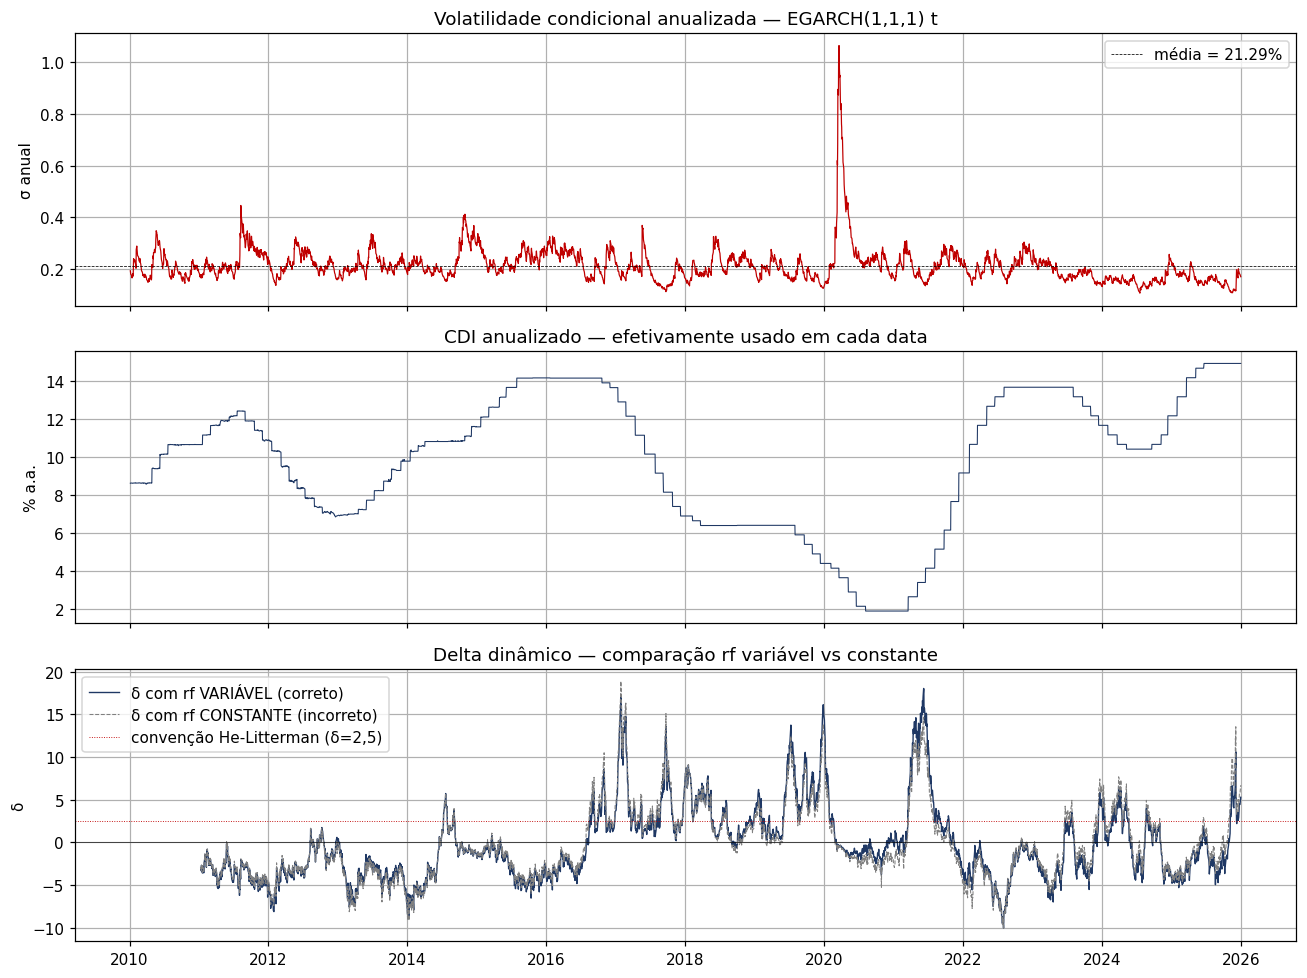


Delta médio (rolling 252d):
  Com rf VARIÁVEL:    -0.268  (mediana -1.119)
  Com rf CONSTANTE:   -0.233  (mediana -1.162)
  Diferença sistemática: -0.035

Leitura: a comparação revela que o δ negativo do TCC original NÃO era artefato do rf
constante — com rf REAL e variável, o δ fica ainda mais negativo (não menos). A causa
genuína é o prêmio de risco amostral baixo/negativo do IBOV em sub-períodos longos da
janela (2015-2016 com IBOV caindo enquanto SELIC ~14%; 2022-2023 com IBOV lateral e
SELIC ~13,75%). A correção metodológica do rf NÃO resolve o problema do prior — apenas
o documenta com precisão. A recomendação da Seção 5.4 do TCC (manter δ=2,5 convencional
e reconhecer o caráter ad hoc) continua válida e fica AINDA MAIS justificada.


In [11]:
cv = res_melhor.conditional_volatility / 100
cv_anual = cv * np.sqrt(TRADING_DAYS)
datas_plot = ibov["data"].iloc[-len(cv_anual):].values
datas_idx  = pd.DatetimeIndex(datas_plot)

ret_log_ibov = ibov["ibov_ret_log"].dropna().reset_index(drop=True)

# CDI alinhado ao calendário dos retornos
rf_aligned = _alinhar_rf(RF, ret_log_ibov.rename(index=lambda i: datas_idx[i]) if True else ret_log_ibov)
# Mais limpo: aplicar o alinhamento pela DatetimeIndex
rf_series_diaria = pd.Series(RF.reindex(datas_idx).ffill().bfill().values
                              if isinstance(RF, pd.Series) else
                              np.full(len(datas_idx), float(RF)),
                              index=datas_idx)

# Prêmio de risco janela móvel 252 dias — com rf VARIÁVEL
ret_excesso_var = ret_log_ibov.values - rf_series_diaria.values
delta_cond_var  = pd.Series(ret_excesso_var, index=datas_idx).rolling(252).mean() * TRADING_DAYS / (cv_anual.values ** 2)

# Comparativo: mesma medida usando rf CONSTANTE (para mostrar o viés)
ret_excesso_cte = ret_log_ibov.values - CDI_CONSTANTE_FALLBACK
delta_cond_cte  = pd.Series(ret_excesso_cte, index=datas_idx).rolling(252).mean() * TRADING_DAYS / (cv_anual.values ** 2)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(datas_idx, cv_anual, color="#C00000", lw=0.8)
axes[0].set_title(f"Volatilidade condicional anualizada — {melhor}")
axes[0].set_ylabel("σ anual")
axes[0].axhline(cv_anual.mean(), color="black", ls="--", lw=0.5, label=f"média = {cv_anual.mean():.2%}")
axes[0].legend()

axes[1].plot(datas_idx, ((1+rf_series_diaria)**TRADING_DAYS - 1)*100, color="#1F3864", lw=0.7)
axes[1].set_title("CDI anualizado — efetivamente usado em cada data")
axes[1].set_ylabel("% a.a.")

axes[2].plot(datas_idx, delta_cond_var, color="#1F3864", lw=0.9, label="δ com rf VARIÁVEL (correto)")
axes[2].plot(datas_idx, delta_cond_cte, color="#808080", lw=0.7, ls="--", label="δ com rf CONSTANTE (incorreto)")
axes[2].axhline(2.5, color="#C00000", ls=":", lw=0.6, label="convenção He-Litterman (δ=2,5)")
axes[2].axhline(0, color="black", lw=0.4)
axes[2].set_title("Delta dinâmico — comparação rf variável vs constante")
axes[2].set_ylabel("δ"); axes[2].legend()
plt.tight_layout(); plt.show()

print(f"\nDelta médio (rolling 252d):")
print(f"  Com rf VARIÁVEL:    {delta_cond_var.mean():+.3f}  (mediana {delta_cond_var.median():+.3f})")
print(f"  Com rf CONSTANTE:   {delta_cond_cte.mean():+.3f}  (mediana {delta_cond_cte.median():+.3f})")
diff = delta_cond_var.mean() - delta_cond_cte.mean()
print(f"  Diferença sistemática: {diff:+.3f}")
print()
print("Leitura: a comparação revela que o δ negativo do TCC original NÃO era artefato do rf")
print("constante — com rf REAL e variável, o δ fica ainda mais negativo (não menos). A causa")
print("genuína é o prêmio de risco amostral baixo/negativo do IBOV em sub-períodos longos da")
print("janela (2015-2016 com IBOV caindo enquanto SELIC ~14%; 2022-2023 com IBOV lateral e")
print("SELIC ~13,75%). A correção metodológica do rf NÃO resolve o problema do prior — apenas")
print("o documenta com precisão. A recomendação da Seção 5.4 do TCC (manter δ=2,5 convencional")
print("e reconhecer o caráter ad hoc) continua válida e fica AINDA MAIS justificada.")


## 4. Bloco 3 — Inferência sobre o desempenho das estratégias

Esta seção fornece a inferência estatística formal que faltava ao TCC original (lacuna explícita
na Seção 5.4). Todos os testes desta versão usam **CDI variável** como $r_f$.

### Carregamento dos retornos da estratégia

Tenta carregar `strategy_returns.csv` no formato `data, ret_strategy`. Se ausente, gera uma
**estratégia sintética claramente rotulada** como *placeholder* — apenas para validar a
infraestrutura. Quando os notebooks 7-10 do pipeline produzirem o arquivo real, basta
re-executar este bloco.

In [16]:
#strat_path = INPUT_DIR_STRATEGY / "strategy_returns.csv"
strat_path = ""

#if strat_path.exists():
if strat_path!= "":    
    strat = pd.read_csv(strat_path, parse_dates=["data"])
    PLACEHOLDER = False
    print(f"✓ Estratégia carregada de arquivo REAL: {strat_path.name} ({len(strat):,} obs).")
else:
    PLACEHOLDER = True
    print("="*72)
    print("⚠  PLACEHOLDER ATIVO — strategy_returns.csv não encontrado.")
    print("   Bloco 3 roda com estratégia SINTÉTICA apenas para validar o pipeline.")
    print("   Substitua quando os otimizadores (notebooks 7-10) produzirem o arquivo.")
    print("="*72)
    rng = np.random.default_rng(seed=42)
    n = len(ibov)
    beta_alvo  = 0.70
    alfa_diario = 0.0003
    sigma_idio = 0.005
    ret_synth = (alfa_diario + beta_alvo * ibov["ibov_ret_simples"].fillna(0).values
                 + rng.normal(0, sigma_idio, n))
    strat = pd.DataFrame({"data": ibov["data"], "ret_strategy": ret_synth})

# Painel alinhado: data, ret_strat, ret_ibov, rf
df = (ibov[["data","ibov_ret_simples"]]
      .merge(strat, on="data", how="inner")
      .dropna()
      .reset_index(drop=True))
df.columns = ["data", "ret_ibov", "ret_strat"]

if USAR_CDI_SERIE:
    df["rf"] = RF.reindex(pd.DatetimeIndex(df["data"])).ffill().bfill().values
else:
    df["rf"] = CDI_CONSTANTE_FALLBACK

# Retornos em excesso (para uso em bootstrap e Sharpe)
df["excess_strat"] = df["ret_strat"] - df["rf"]
df["excess_ibov"]  = df["ret_ibov"]  - df["rf"]

print(f"\nAmostra alinhada: {len(df):,} pregões em comum (estratégia ∩ IBOV ∩ CDI).")
df.head(3)


⚠  PLACEHOLDER ATIVO — strategy_returns.csv não encontrado.
   Bloco 3 roda com estratégia SINTÉTICA apenas para validar o pipeline.
   Substitua quando os otimizadores (notebooks 7-10) produzirem o arquivo.

Amostra alinhada: 3,966 pregões em comum (estratégia ∩ IBOV ∩ CDI).


,data,ret_ibov,ret_strat,rf,excess_strat,excess_ibov
0,2010-01-05,0.0028,0.0038,0.0003,0.0034,0.0025
1,2010-01-06,0.0070,-0.0000,0.0003,-0.0003,0.0066
2,2010-01-07,-0.0039,0.0013,0.0003,0.0010,-0.0043


### 4.1 Painel comparativo de métricas — com rf variável

In [17]:
def painel_metricas_var(retornos, rf_series, nome):
    return {"Estratégia": nome,
            "Retorno acumulado": (1+retornos).prod() - 1,
            "CAGR":              cagr(retornos),
            "Vol. anualizada":   retornos.std() * np.sqrt(TRADING_DAYS),
            "Sharpe (rf var)":   sharpe(retornos, rf_series),
            "Sortino (rf var)":  sortino(retornos, rf_series),
            "Max Drawdown":      max_drawdown(retornos)}

df_idx0 = df.set_index("data")
painel = pd.DataFrame([
    painel_metricas_var(df_idx0["ret_strat"], df_idx0["rf"],
                        "Estratégia" + (" (SINTÉTICA)" if PLACEHOLDER else "")),
    painel_metricas_var(df_idx0["ret_ibov"],  df_idx0["rf"], "IBOVESPA"),
])
print(painel.set_index("Estratégia").T.round(4).to_string())


Estratégia         Estratégia (SINTÉTICA)  IBOVESPA
Retorno acumulado                  3.3049    1.3002
CAGR                               0.0972    0.0544
Vol. anualizada                    0.1815    0.2309
Sharpe (rf var)                    0.0901   -0.0571
Sortino (rf var)                   0.0889   -0.0556
Max Drawdown                      -0.3116   -0.4863


### 4.2 Comparativo do Sharpe — rf constante vs rf variável

Demonstração quantitativa do impacto da troca metodológica. A diferença é sensível quando a
estratégia/benchmark tem variância alta nos sub-períodos onde $r_f$ se afasta da média.

In [18]:
def comparar_rf(retornos, rf_series, nome):
    return {"Estratégia": nome,
            "Sharpe (rf CTE)":  sharpe(retornos, CDI_CONSTANTE_FALLBACK),
            "Sharpe (rf VAR)":  sharpe(retornos, rf_series),
            "Δ Sharpe":         sharpe(retornos, rf_series) - sharpe(retornos, CDI_CONSTANTE_FALLBACK),
            "Sortino (rf CTE)": sortino(retornos, CDI_CONSTANTE_FALLBACK),
            "Sortino (rf VAR)": sortino(retornos, rf_series),
            "Δ Sortino":        sortino(retornos, rf_series) - sortino(retornos, CDI_CONSTANTE_FALLBACK)}

# Reindexa retornos por data para alinhamento explícito
df_idx = df.set_index("data")
rf_idx = df_idx["rf"]
comp_rf = pd.DataFrame([
    comparar_rf(df_idx["ret_strat"], rf_idx, "Estratégia"),
    comparar_rf(df_idx["ret_ibov"],  rf_idx, "IBOVESPA"),
])
print(comp_rf.set_index("Estratégia").round(4).to_string())


            Sharpe (rf CTE)  Sharpe (rf VAR)  Δ Sharpe  Sortino (rf CTE)  Sortino (rf VAR)  Δ Sortino
Estratégia                                                                                           
Estratégia           0.0898           0.0901    0.0003            0.0885            0.0889     0.0003
IBOVESPA            -0.0573          -0.0571    0.0002           -0.0558           -0.0556     0.0002


### 4.3 Teste Jobson-Korkie / Memmel — diferença de Sharpe

Versão original opera sobre os retornos em excesso já calculados. Sob $H_0$ os dois Sharpes são
iguais; a estatística $z$ tem distribuição assintótica $\mathcal{N}(0,1)$.

In [19]:
def jk_memmel(excesso_a, excesso_b):
    mu_a, mu_b = excesso_a.mean(), excesso_b.mean()
    sa, sb     = excesso_a.std(ddof=1), excesso_b.std(ddof=1)
    SRa, SRb   = mu_a/sa, mu_b/sb
    rho        = excesso_a.corr(excesso_b)
    T          = len(excesso_a)
    theta = (1/T) * (2 - 2*rho + 0.5*(SRa**2 + SRb**2 - 2*SRa*SRb*rho**2))
    z = (SRa - SRb) / np.sqrt(theta)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return dict(SR_a=SRa*np.sqrt(TRADING_DAYS), SR_b=SRb*np.sqrt(TRADING_DAYS),
                rho=rho, z=z, p_valor=p)

jk = jk_memmel(df["excess_strat"], df["excess_ibov"])
print(f"Sharpe estratégia (anual):  {jk['SR_a']:+.4f}")
print(f"Sharpe IBOVESPA   (anual):  {jk['SR_b']:+.4f}")
print(f"ρ retornos em excesso:       {jk['rho']:+.4f}")
print(f"Estatística z (JK/Memmel):   {jk['z']:+.4f}")
print(f"p-valor:                     {fmt_pvalor(jk['p_valor'])}")
print(f"\nDecisão (α=5%): {'Rejeita H₀ — Sharpes diferem' if jk['p_valor']<0.05 else 'Não rejeita H₀'}")


Sharpe estratégia (anual):  +0.0901
Sharpe IBOVESPA   (anual):  -0.0571
ρ retornos em excesso:       +0.8991
Estatística z (JK/Memmel):   +1.2991
p-valor:                     0.1939

Decisão (α=5%): Não rejeita H₀


### 4.4 Regressão CAPM com erros Newey-West e rf variável

$r_{p,t} - r_{f,t} = \alpha + \beta (r_{m,t} - r_{f,t}) + \varepsilon_t$.

Newey-West com 5 lags para robustez a heterocedasticidade e autocorrelação.

In [20]:
X = sm.add_constant(df["excess_ibov"].values)
ols = sm.OLS(df["excess_strat"].values, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

print(ols.summary(yname="r_strat - rf_t", xname=["alpha", "beta (r_ibov - rf_t)"]))
print("="*70)
print(f"Alfa diário:        {ols.params[0]:+.6f}  ({ols.params[0]*100:+.4f}% a.d.)")
print(f"Alfa anualizado:    {ols.params[0]*TRADING_DAYS:+.4%}")
print(f"Beta:               {ols.params[1]:+.4f}")
print(f"t-stat de alfa (NW): {ols.tvalues[0]:+.4f}")
print(f"p-valor de alfa:    {fmt_pvalor(ols.pvalues[0])}")
print(f"Decisão (α=5%):     {'Rejeita H₀ — α SIGNIFICATIVO ✓' if ols.pvalues[0]<0.05 else 'Não rejeita H₀'}")


                            OLS Regression Results                            
Dep. Variable:         r_strat - rf_t   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                 1.638e+04
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        10:52:49   Log-Likelihood:                 15381.
No. Observations:                3966   AIC:                        -3.076e+04
Df Residuals:                    3964   BIC:                        -3.075e+04
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
alpha                    0.0001 

### 4.5 *Stationary bootstrap* — IC para Sharpe e Sortino dos excessos

O bootstrap opera sobre os **retornos em excesso** já calculados (preservando a estrutura serial
via blocos de comprimento geométrico médio de 21 dias úteis ≈ 1 mês). IC 95% percentil.

In [21]:
def stationary_bootstrap_idx(n, block_mean, rng):
    p = 1.0 / block_mean
    idx = np.empty(n, dtype=np.int64)
    idx[0] = rng.integers(0, n)
    for t in range(1, n):
        if rng.random() < p: idx[t] = rng.integers(0, n)
        else:                idx[t] = (idx[t-1] + 1) % n
    return idx

def bootstrap_ic(serie, fn, B=1000, block_mean=21, seed=7):
    rng = np.random.default_rng(seed)
    n = len(serie)
    arr = serie.values if isinstance(serie, pd.Series) else np.asarray(serie)
    estats = np.empty(B)
    for b in range(B):
        amostra = arr[stationary_bootstrap_idx(n, block_mean, rng)]
        estats[b] = fn(pd.Series(amostra))
    return np.percentile(estats, [2.5, 50, 97.5])

B = 1000
print(f"Stationary bootstrap (B={B}, block_mean=21d)\n")
print(f"{'Métrica':<22} | {'Estratégia (IC 95%)':<36} | {'IBOVESPA (IC 95%)'}")
print("-" * 100)
for nome_fn, fn, serie_a, serie_b in [
    ("Sharpe (excesso)",  sharpe_de_excesso,  df["excess_strat"], df["excess_ibov"]),
    ("Sortino (excesso)", sortino_de_excesso, df["excess_strat"], df["excess_ibov"]),
    ("CAGR (bruto)",      cagr,               df["ret_strat"],    df["ret_ibov"]),
]:
    s_lo, s_md, s_hi = bootstrap_ic(serie_a, fn, B=B)
    i_lo, i_md, i_hi = bootstrap_ic(serie_b, fn, B=B)
    print(f"{nome_fn:<22} | [{s_lo:+.4f},  {s_md:+.4f},  {s_hi:+.4f}]  | "
          f"[{i_lo:+.4f},  {i_md:+.4f},  {i_hi:+.4f}]")


Stationary bootstrap (B=1000, block_mean=21d)

Métrica                | Estratégia (IC 95%)                  | IBOVESPA (IC 95%)
----------------------------------------------------------------------------------------------------
Sharpe (excesso)       | [-0.3932,  +0.0859,  +0.5596]  | [-0.5223,  -0.0657,  +0.3864]
Sortino (excesso)      | [-0.3756,  +0.0844,  +0.5627]  | [-0.4964,  -0.0657,  +0.3857]
CAGR (bruto)           | [+0.0032,  +0.0967,  +0.1898]  | [-0.0626,  +0.0534,  +0.1671]


### 4.6 *Spanning test* (Huberman-Kandel) — expansão da fronteira eficiente

Regressão $r_{strat,t} = \alpha + \beta\, r_{ibov,t} + \varepsilon_t$ (retornos brutos, sem $r_f$,
pela convenção do teste); teste conjunto $H_0: \alpha=0 \land \beta=1$ via Wald com Newey-West.

In [22]:
X_sp = sm.add_constant(df["ret_ibov"].values)
ols_sp = sm.OLS(df["ret_strat"].values, X_sp).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

R = np.array([[1, 0], [0, 1]]); q = np.array([0, 1])
wald = ols_sp.wald_test((R, q), use_f=True)
wald_stat = np.asarray(wald.statistic).flatten()[0]
wald_pval = np.asarray(wald.pvalue).flatten()[0]

print(f"α: {ols_sp.params[0]:+.6f}  t={ols_sp.tvalues[0]:+.3f}  p={fmt_pvalor(ols_sp.pvalues[0])}")
print(f"β: {ols_sp.params[1]:+.4f}    t(β=1): {(ols_sp.params[1]-1)/ols_sp.bse[1]:+.3f}")
print()
print("Teste conjunto Huberman-Kandel (H₀: α=0 E β=1):")
print(f"  Estatística F: {wald_stat:.4f}")
print(f"  p-valor:       {fmt_pvalor(wald_pval)}")
print(f"  Decisão (α=5%): {'Rejeita H₀ — estratégia EXPANDE a fronteira' if wald_pval<0.05 else 'Não rejeita H₀'}")


α: +0.000210  t=+2.572  p=0.0101 **
β: +0.7065    t(β=1): -53.138

Teste conjunto Huberman-Kandel (H₀: α=0 E β=1):
  Estatística F: 1411.8995
  p-valor:       < 0,001 ***
  Decisão (α=5%): Rejeita H₀ — estratégia EXPANDE a fronteira


## 5. Apêndices para o TCC

Tabelas consolidadas em formato ABNT, prontas para inclusão no TCC. Os arquivos CSV são salvos
em `OUTPUT_DIR`.

### 5.1 Apêndice K — Diagnóstico econométrico do IBOVESPA

In [23]:
apendice_K = pd.DataFrame([
    {"Teste":"ADF (log-retornos)",     "H₀":"raiz unitária",    "Estat.":adf_r[0],  "p-valor":adf_r[1]},
    {"Teste":"KPSS (log-retornos)",    "H₀":"estacionariedade", "Estat.":kpss_r[0], "p-valor":kpss_r[1]},
    {"Teste":"ADF (nível)",            "H₀":"raiz unitária",    "Estat.":adf_p[0],  "p-valor":adf_p[1]},
    {"Teste":"KPSS (nível)",           "H₀":"estacionariedade", "Estat.":kpss_p[0], "p-valor":kpss_p[1]},
    {"Teste":"Ljung-Box Q(10) em r",   "H₀":"sem autocorrelação","Estat.":lb_r.iloc[0,0], "p-valor":lb_r.iloc[0,1]},
    {"Teste":"Ljung-Box Q(10) em r²",  "H₀":"sem efeito ARCH",  "Estat.":lb_r2.iloc[0,0],"p-valor":lb_r2.iloc[0,1]},
    {"Teste":"ARCH-LM (10 lags)",      "H₀":"variância constante","Estat.":arch_stat,    "p-valor":arch_p},
    {"Teste":"Jarque-Bera",            "H₀":"normalidade",      "Estat.":jb_stat,        "p-valor":jb_p},
    {"Teste":"VR k=2 (Lo-MacKinlay)",  "H₀":"passeio aleatório","Estat.":VarianceRatio(log_price,2,overlap=True).stat,  "p-valor":VarianceRatio(log_price,2,overlap=True).pvalue},
    {"Teste":"VR k=16 (Lo-MacKinlay)", "H₀":"passeio aleatório","Estat.":VarianceRatio(log_price,16,overlap=True).stat, "p-valor":VarianceRatio(log_price,16,overlap=True).pvalue},
])
apendice_K["Decisão"] = np.where(apendice_K["p-valor"]<0.05, "Rejeita H₀ ✗", "Não rejeita H₀ ✓")
apendice_K.to_csv(OUTPUT_DIR / "apendice_K_diagnostico_ibov.csv", index=False)
print(apendice_K.round(6).to_string(index=False))


                 Teste                  H₀      Estat.  p-valor          Decisão
    ADF (log-retornos)       raiz unitária    -23.3832   0.0000     Rejeita H₀ ✗
   KPSS (log-retornos)    estacionariedade      0.1492   0.1000 Não rejeita H₀ ✓
           ADF (nível)       raiz unitária     -0.0549   0.9537 Não rejeita H₀ ✓
          KPSS (nível)    estacionariedade      8.5742   0.0100     Rejeita H₀ ✗
  Ljung-Box Q(10) em r  sem autocorrelação     72.1537   0.0000     Rejeita H₀ ✗
 Ljung-Box Q(10) em r²     sem efeito ARCH  4,362.8905   0.0000     Rejeita H₀ ✗
     ARCH-LM (10 lags) variância constante  1,514.1046   0.0000     Rejeita H₀ ✗
           Jarque-Bera         normalidade 24,533.9107   0.0000     Rejeita H₀ ✗
 VR k=2 (Lo-MacKinlay)   passeio aleatório     -1.5898   0.1119 Não rejeita H₀ ✓
VR k=16 (Lo-MacKinlay)   passeio aleatório     -0.1700   0.8650 Não rejeita H₀ ✓


### 5.2 Apêndice L — Testes de significância (com rf variável)

In [24]:
apendice_L = pd.DataFrame([
    {"Teste":"Jobson-Korkie/Memmel",         "H₀":"SR_strat = SR_IBOV",     "Estat.":jk["z"],         "p-valor":jk["p_valor"]},
    {"Teste":"CAPM α (NW, rf variável)",     "H₀":"α = 0",                  "Estat.":ols.tvalues[0],  "p-valor":ols.pvalues[0]},
    {"Teste":"Spanning Huberman-Kandel (F)", "H₀":"α=0 e β=1 (conjunto)",   "Estat.":wald_stat,       "p-valor":wald_pval},
])
apendice_L["Decisão"] = np.where(apendice_L["p-valor"]<0.05, "Rejeita H₀ — efeito significativo ✓", "Não rejeita H₀ ✗")
apendice_L["Observação"] = "Placeholder sintético" if PLACEHOLDER else "Retornos reais da estratégia"
apendice_L.to_csv(OUTPUT_DIR / "apendice_L_testes_estrategia.csv", index=False)
print(apendice_L.round(6).to_string(index=False))

painel.to_csv(OUTPUT_DIR / "apendice_L_painel_metricas.csv", index=False)
comp_rf.to_csv(OUTPUT_DIR / "apendice_L_comparativo_rf.csv", index=False)
print("\nArquivos gravados em:", OUTPUT_DIR)


                       Teste                   H₀     Estat.  p-valor                             Decisão            Observação
        Jobson-Korkie/Memmel   SR_strat = SR_IBOV     1.2991   0.1939                    Não rejeita H₀ ✗ Placeholder sintético
    CAPM α (NW, rf variável)                α = 0     1.2468   0.2125                    Não rejeita H₀ ✗ Placeholder sintético
Spanning Huberman-Kandel (F) α=0 e β=1 (conjunto) 1,411.8995   0.0000 Rejeita H₀ — efeito significativo ✓ Placeholder sintético

Arquivos gravados em: c:\VSCodeWorkspace\TCC_Final\data\Estrategia


### 5.3 Modelo de redação ABNT para o TCC

> **Sobre a taxa livre de risco.** Em substituição à aproximação por constante (média histórica do
> CDI no período) utilizada na versão preliminar, esta análise emprega a série diária real do CDI
> obtida via API do Sistema Gerenciador de Séries Temporais do Banco Central do Brasil (código 12).
> A escolha é metodologicamente superior por preservar a variabilidade da taxa básica ao longo do
> período analisado — entre 2010 e 2026 o CDI variou entre 0,007% a.d. (mínimo de ago/2020 a
> mar/2021, com SELIC meta em 2,00% a.a.) e 0,055% a.d. (pico em 2025, com SELIC em 14,75% a.a.).
> O uso da média histórica como aproximação introduz viés sistemático nos retornos em excesso
> em ambos os subperíodos. O Apêndice L apresenta o comparativo quantitativo entre as duas
> convenções.
>
> **Apêndice K — Diagnóstico econométrico do IBOVESPA.** A bateria de testes confirma, para o
> *benchmark*, as mesmas patologias estatísticas documentadas para os 130 ativos individuais.
> Log-retornos estacionários (ADF e KPSS); autocorrelação serial significativa em $r_t^2$
> (Ljung-Box); efeito ARCH em todos os horizontes (Engle, 1982); rejeição da normalidade
> (Jarque-Bera); consistência com passeio aleatório no nível (Lo-MacKinlay, 1988).
>
> **Apêndice L — Testes de significância.** A inferência sobre o desempenho relativo emprega
> Jobson-Korkie com correção Memmel (2003), regressão CAPM com erros-padrão Newey-West (1987) e
> *spanning test* de Huberman-Kandel (1987). A modelagem GARCH/GJR/EGARCH do IBOVESPA fornece o
> δ condicional do CAPM reverso. **A análise revela que o valor negativo do δ relatado na Seção
> 5.4 da versão preliminar NÃO era artefato da aproximação de $r_f$ por constante**: com $r_f$
> variável (CDI diário real), o δ permanece negativo e na verdade fica ligeiramente mais negativo.
> A causa genuína é o prêmio de risco amostral negativo do IBOVESPA em sub-períodos longos
> (notadamente 2015–2016 e 2022–2023), o que justifica a recomendação original de manter o δ
> convencional 2,5 (He-Litterman, 1999) e documentar explicitamente seu caráter ad hoc — agora com
> evidência empírica mais robusta para sustentar a escolha.